<a href="https://colab.research.google.com/github/PrantoMondol11/Machine-learning-/blob/main/Gradient%20boost%20algo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
np.random.seed(42)
X=np.random.rand(100,1)-.5
y=3*X[:,0]**2 + 0.05* np.random.randn(100)

In [3]:
X

array([[-0.12545988],
       [ 0.45071431],
       [ 0.23199394],
       [ 0.09865848],
       [-0.34398136],
       [-0.34400548],
       [-0.44191639],
       [ 0.36617615],
       [ 0.10111501],
       [ 0.20807258],
       [-0.47941551],
       [ 0.46990985],
       [ 0.33244264],
       [-0.28766089],
       [-0.31817503],
       [-0.31659549],
       [-0.19575776],
       [ 0.02475643],
       [-0.06805498],
       [-0.20877086],
       [ 0.11185289],
       [-0.36050614],
       [-0.20785535],
       [-0.13363816],
       [-0.04393002],
       [ 0.28517596],
       [-0.30032622],
       [ 0.01423444],
       [ 0.09241457],
       [-0.45354959],
       [ 0.10754485],
       [-0.32947588],
       [-0.43494841],
       [ 0.44888554],
       [ 0.46563203],
       [ 0.30839735],
       [-0.19538623],
       [-0.40232789],
       [ 0.18423303],
       [-0.05984751],
       [-0.37796177],
       [-0.00482309],
       [-0.46561148],
       [ 0.4093204 ],
       [-0.24122002],
       [ 0

In [4]:
df=pd.DataFrame()
df['x']=X.reshape(100)
df['y']=y

In [5]:
df

,x,y
0,-0.125460,0.051573
1,0.450714,0.594480
2,0.231994,0.166052
3,0.098658,-0.070178
4,-0.343981,0.343986
...,...,...
95,-0.006204,-0.040675
96,0.022733,-0.002305
97,-0.072459,0.032809
98,-0.474581,0.689516


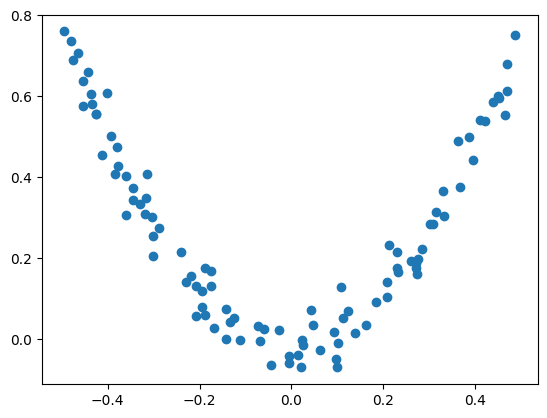

In [7]:
plt.scatter(df["x"],df["y"])

In [9]:
df['pred1']=df['y'].mean()

In [10]:
df["res1"]=df["y"]-df["pred1"]

In [11]:
df

,x,y,pred1,res1
0,-0.125460,0.051573,0.265458,-0.213885
1,0.450714,0.594480,0.265458,0.329021
2,0.231994,0.166052,0.265458,-0.099407
3,0.098658,-0.070178,0.265458,-0.335636
4,-0.343981,0.343986,0.265458,0.078528
...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133
96,0.022733,-0.002305,0.265458,-0.267763
97,-0.072459,0.032809,0.265458,-0.232650
98,-0.474581,0.689516,0.265458,0.424057


In [12]:
from sklearn.tree import DecisionTreeRegressor

In [15]:
clf1=DecisionTreeRegressor(max_leaf_nodes=8)

In [19]:
clf1.fit(df["x"].values.reshape(100,1),df['res1'].values)

DecisionTreeRegressor(max_depth=8)

In [21]:
X_test=np.linspace(-0.5,0.5,500)
y_pred=0.265458+clf1.predict(X_test.reshape(500,1))

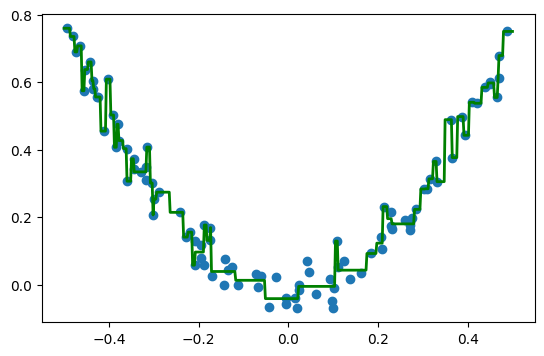

In [27]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.plot(X_test,y_pred,linewidth=2,color="green")
plt.scatter(df['x'],df['y'])

In [28]:
df["pred2"]=0.0265458+ clf1.predict(df["x"].values.reshape(100,1))

In [30]:
df["res2"]=df['y']-df['pred2']

In [31]:
df

,x,y,pred1,res1,pred2,res2
0,-0.125460,0.051573,0.265458,-0.213885,-0.200031,0.251604
1,0.450714,0.594480,0.265458,0.329021,0.358713,0.235766
2,0.231994,0.166052,0.265458,-0.099407,-0.058971,0.225023
3,0.098658,-0.070178,0.265458,-0.335636,-0.244214,0.174036
4,-0.343981,0.343986,0.265458,0.078528,0.095104,0.248881
...,...,...,...,...,...,...
95,-0.006204,-0.040675,0.265458,-0.306133,-0.280488,0.239813
96,0.022733,-0.002305,0.265458,-0.267763,-0.244214,0.241909
97,-0.072459,0.032809,0.265458,-0.232650,-0.226179,0.258987
98,-0.474581,0.689516,0.265458,0.424057,0.450603,0.238913


In [33]:
clf2=DecisionTreeRegressor(max_leaf_nodes=8)

In [34]:
clf2.fit(df['x'].values.reshape(100,1),df['res2'])

DecisionTreeRegressor(max_leaf_nodes=8)

In [36]:
y_pred=0.265458 + sum(clf.predict(X_test.reshape(-1,1)) for clf in [clf1,clf2])

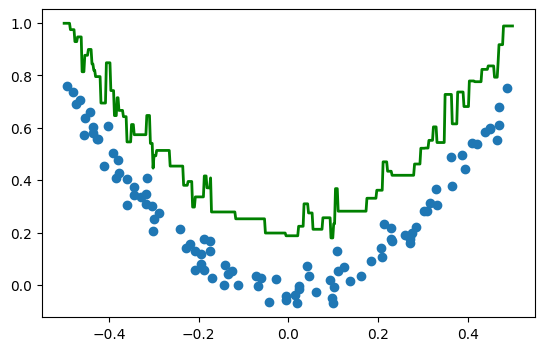

In [37]:
plt.figure(figsize=(14,4))
plt.subplot(121)
plt.plot(X_test,y_pred,linewidth=2,color="green")
plt.scatter(df['x'],df['y'])

In [48]:
def gradient_boost(X,y,number,lr , count=1 ,regs=None,foo=None):

  if regs is None:
      regs = []
  if number == 0:
     return regs,foo
  else:
      #gradient boosting algo
      if count ==1 :
        foo=np.mean(y)
        residuals=y-foo
      else:
        residuals=y-(foo+lr*sum(model.predict(X) for model in regs))

      clf=DecisionTreeRegressor(max_depth=5,random_state=42)
      clf.fit(X,residuals)
      regs.append(clf)
  return gradient_boost(X,residuals,number-1,lr,count+1,regs,foo)

In [49]:
model,foo=gradient_boost(df["x"].values.reshape(100,1),df['y'].values,5,0.01)



In [57]:
def predict(X,model,foo,lr):
  prediction=foo
  for models in model:
    prediction+=lr*models.predict(X)
  return prediction

In [58]:
x_test=np.linspace(-0.5,0.5,500)

In [66]:
predict(x_test.reshape(500,1),model,foo,0.1)

array([ 0.24126533,  0.24126533,  0.24126533,  0.24126533,  0.24126533,
        0.24126533,  0.24126533,  0.22957972,  0.22957972,  0.22957972,
        0.22957972,  0.22957972,  0.20759947,  0.20759947,  0.20759947,
        0.21624695,  0.21624695,  0.21624695,  0.21624695,  0.21624695,
        0.15235999,  0.15235999,  0.15235999,  0.18792484,  0.18792484,
        0.18792484,  0.18792484,  0.18792484,  0.18792484,  0.18792484,
        0.18792484,  0.16212984,  0.16212984,  0.15974447,  0.15974447,
        0.13712159,  0.13712159,  0.13712159,  0.13713914,  0.13713914,
        0.13713914,  0.1076146 ,  0.1076146 ,  0.1076146 ,  0.1076146 ,
        0.1076146 ,  0.1076146 ,  0.15389604,  0.15389604,  0.15389604,
        0.15389604,  0.15389604,  0.13277046,  0.13277046,  0.13277046,
        0.13277046,  0.07190993,  0.07190993,  0.07190993,  0.09307611,
        0.09307611,  0.09307611,  0.09307611,  0.09307611,  0.09307611,
        0.09307611,  0.06998651,  0.06998651,  0.06998651,  0.06

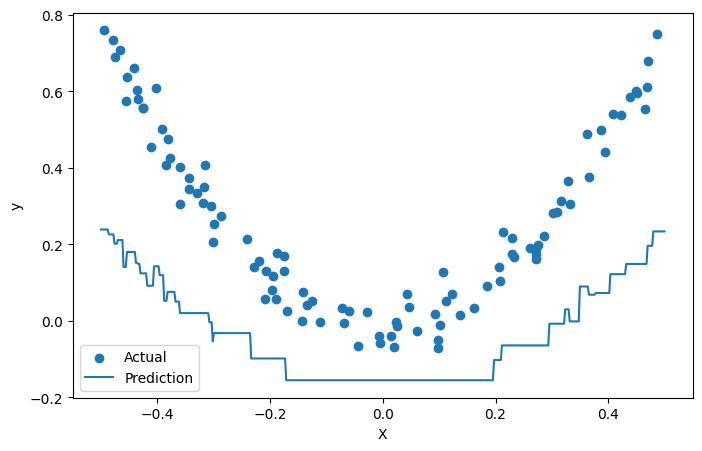

In [77]:
import matplotlib.pyplot as plt

y_pred = predict(x_test.reshape(500,1), model, foo, 0.11)

plt.figure(figsize=(8,5))


plt.scatter(df["x"].values.reshape(100,1), df['y'].values, label="Actual")


plt.plot(x_test, y_pred.reshape(500,1), label="Prediction")

plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

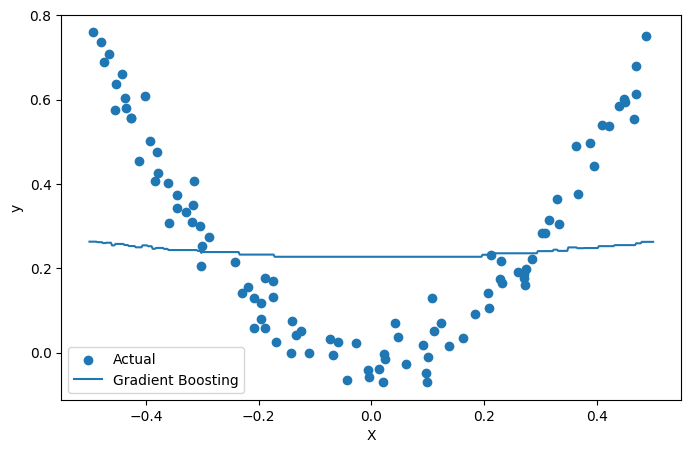

In [72]:
import matplotlib.pyplot as plt
import numpy as np

# prediction
y_pred = predict(
    x_test.reshape(500,1),
    model,
    foo,
    .01
)

# sort x for smooth curve
idx = np.argsort(x_test)

x_sorted = x_test[idx]
y_pred_sorted = y_pred[idx]


plt.figure(figsize=(8,5))

# actual data
plt.scatter(
    df["x"].values,
    df["y"].values,
    label="Actual"
)

# model curve
plt.plot(
    x_sorted,
    y_pred_sorted,
    label="Gradient Boosting"
)

plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()